#### Model Training

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor


In [57]:
df=pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [58]:
df['Total_Score']=df['math score']+df['reading score']+df['writing score']
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [59]:
X=df.drop(columns=['Total_Score'],axis=1)

In [60]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [61]:
y=df['Total_Score']
y

0      218
1      247
2      278
3      148
4      229
      ... 
995    282
996    172
997    195
998    223
999    249
Name: Total_Score, Length: 1000, dtype: int64

In [62]:
### Create column transformer with 3 types of object
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',cat_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]
)

In [63]:
X=preprocessor.fit_transform(X)

In [64]:
### Train_test_spilt
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 20), (200, 20))

#### Create an evaluation Function to give all matrics after model training


In [65]:
def evaluate_metrics(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    R2_score=r2_score(true,predicted)
    return rmse,mae,R2_score

✔ Model Evaluation Pipeline

or

✔ Multiple Model Benchmarking Loop

Because it:

Trains each model

Makes predictions

Computes evaluation metrics

Prints results

Stores model names & R² scores-create funciton

In [66]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor(),
    'XGBoostRegressor': XGBRegressor(),
    'CatBoostRegressor': CatBoostRegressor(verbose=False)
}

model_lst=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    #Make prediction
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    ## Evaluate Train and Test dataset
    model_train_mae,model_train_rmse,model_train_r2=evaluate_metrics(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2=evaluate_metrics(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_lst.append(list(models.keys())[i])

    print('Model performance for training set:')
    print("- Root Mean Square Error: {:.4f}".format(model_train_rmse))
    print("-  Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2_score: {:.4f}".format(model_train_r2))

    print('-------------------------------------')
    print('Model performance for test set')
    print("- Root Mean Square Error: {:.4f}".format(model_test_rmse))
    print("-  Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2_score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')






Linear Regression
Model performance for training set:
- Root Mean Square Error: 0.0000
-  Mean Absolute Error: 0.0000
- R2_score: 1.0000
-------------------------------------
Model performance for test set
- Root Mean Square Error: 0.0000
-  Mean Absolute Error: 0.0000
- R2_score: 1.0000


Lasso
Model performance for training set:
- Root Mean Square Error: 0.8505
-  Mean Absolute Error: 1.0644
- R2_score: 0.9994
-------------------------------------
Model performance for test set
- Root Mean Square Error: 0.8764
-  Mean Absolute Error: 1.1139
- R2_score: 0.9994


Ridge
Model performance for training set:
- Root Mean Square Error: 0.0195
-  Mean Absolute Error: 0.0241
- R2_score: 1.0000
-------------------------------------
Model performance for test set
- Root Mean Square Error: 0.0201
-  Mean Absolute Error: 0.0264
- R2_score: 1.0000


SVR
Model performance for training set:
- Root Mean Square Error: 6.6484
-  Mean Absolute Error: 15.2552
- R2_score: 0.8704
---------------------------

In [67]:
# Combine model names and R2 scores
results = list(zip(model_lst, r2_list))

# Sort by R2 descending
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

# Print
print("Model Performance (Sorted by R2 Score - Descending):\n")
for model_name, r2 in results_sorted:
    print(f"{model_name}: R2 = {r2:.4f}")


Model Performance (Sorted by R2 Score - Descending):

Linear Regression: R2 = 1.0000
Ridge: R2 = 1.0000
Lasso: R2 = 0.9994
XGBoostRegressor: R2 = 0.9948
CatBoostRegressor: R2 = 0.9935
Random Forest: R2 = 0.9934
Decision Tree: R2 = 0.9878
KNN: R2 = 0.9560
SVR: R2 = 0.7611


### We can clearly see Linear Regression perform better in this case-So we choose linearRegression model better in this case

### LinearRegression

In [73]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
R2_score=r2_score(y_test,y_pred)
print("R2_score:",R2_score)

R2_score: 1.0


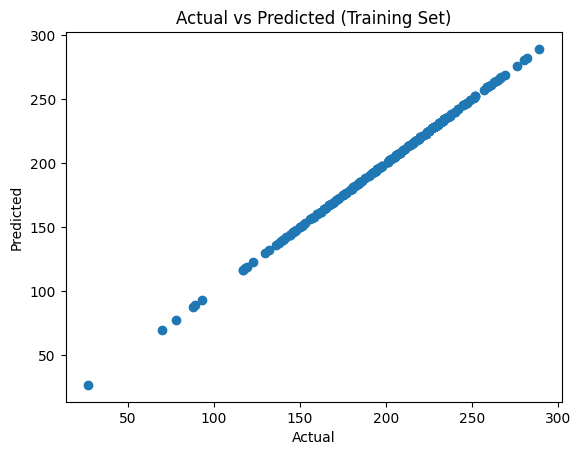

In [84]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel('Predicted')
plt.title("Actual vs Predicted (Training Set)")
plt.show()



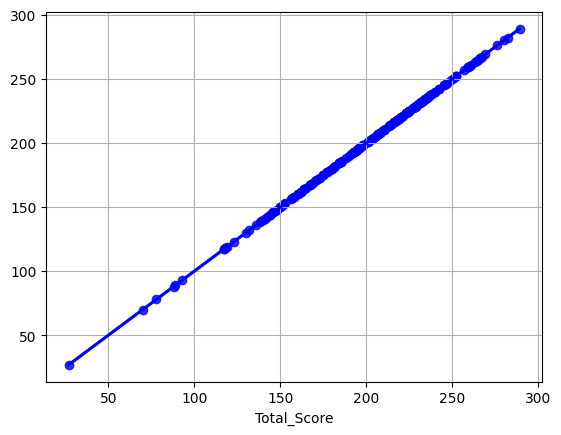

In [92]:
sns.regplot(x=y_test,y=y_pred,marker='o',scatter=True,color='blue')
plt.grid()
plt.show()


### Difference bettween actual and predicted values

In [95]:
pred_diff = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Difference': y_test - y_pred
})

pred_diff

,Actual Value,Predicted Value,Difference
521,261,261.0,0.000000e+00
737,192,192.0,0.000000e+00
740,225,225.0,0.000000e+00
660,224,224.0,0.000000e+00
411,245,245.0,-5.684342e-14
...,...,...,...
408,165,165.0,2.842171e-14
332,171,171.0,5.684342e-14
208,231,231.0,0.000000e+00
613,216,216.0,0.000000e+00
